In [1]:
### Read in loss log and plot
from matplotlib import pyplot as plt
import numpy as np
import os

# Read and concatenate loss files and adjust starting steps
def concat_read (path, files):
    steps = []
    losses = []
    
    step_offset = 0
    
    for fname in files:
        file_steps = []
        file_losses = []
    
        with open(os.path.join(path, fname), "r") as log_file:
            for line in log_file:
                line = line.strip()
                if not line:
                    continue
    
                step_str, loss_str = line.split(",")
                file_steps.append(int(step_str.strip()))
                file_losses.append(float(loss_str.strip()))
    
        # apply offset
        file_steps = [s + step_offset for s in file_steps]
    
        steps.extend(file_steps)
        losses.extend(file_losses)
    
        # update offset using last step in this file
        if file_steps:
            step_offset = file_steps[-1] + 1

    return np.array(steps), np.array(losses)

In [ ]:
# LEGACY Code: when was not doing append
# path = '/global/homes/j/jiarongw/scratch_folder/log1p/waveparts_hist/'
# trainfiles = ["loss_log_1.txt", "loss_log_2.txt", "loss_log_3.txt", "loss_log_4.txt", "loss_log_5.txt", "loss_log_6.txt"]
# testfiles = ["test_loss_log_1.txt", "test_loss_log_2.txt", "test_loss_log_3.txt", 
#              "test_loss_log_4.txt", "test_loss_log_5.txt", "test_loss_log_6.txt"]
# steps, losses = concat_read (path, trainfiles)
# test_steps, test_losses = concat_read (path, testfiles)

In [2]:
path = '/global/homes/j/jiarongw/scratch_folder/final/OPTION3/'
trainfiles = ["loss_log.txt"]
testfiles = ["test_loss_log.txt"]
steps, losses = concat_read (path, trainfiles)
test_steps, test_losses = concat_read (path, testfiles)

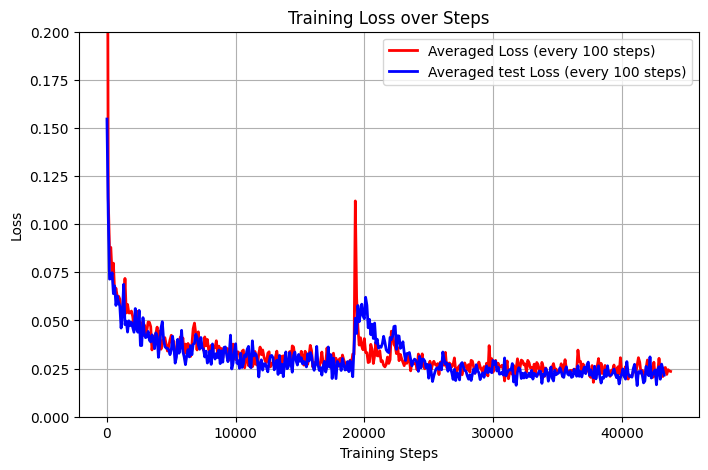

In [3]:
plt.figure(figsize=(8,5))
# plt.plot(steps, losses)
# plt.plot(test_steps, test_losses)
# Plot averaged loss every 50 steps
avg_losses = [np.mean(losses[i:i+100]) for i in range(0, len(losses), 100)]
plt.plot(range(0, len(losses), 100), avg_losses, color='red', linewidth=2, label='Averaged Loss (every 100 steps)')
plt.plot(range(0, len(test_losses)*100, 100), test_losses, color='blue', linewidth=2, label='Averaged test Loss (every 100 steps)')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Training Loss over Steps')
plt.legend()
plt.ylim([0,0.2])
# plt.xlim([0,8])
plt.grid()

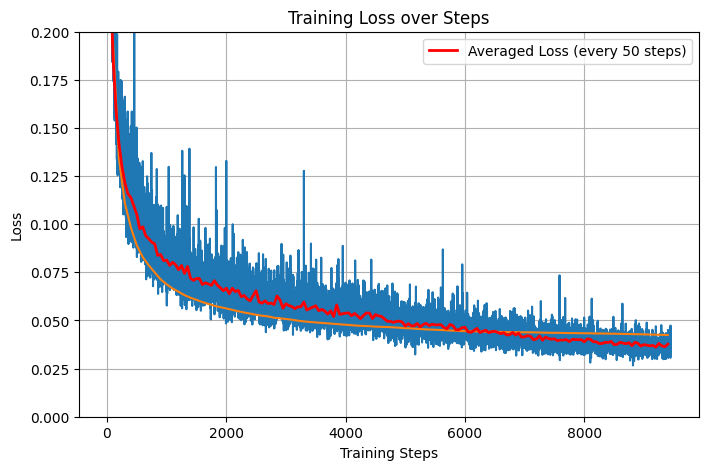

In [10]:
plt.figure(figsize=(8,5))
plt.plot(steps, losses)
plt.plot(test_steps, test_losses)
# Plot averaged loss every 50 steps
avg_losses = [np.mean(losses[i:i+50]) for i in range(0, len(losses), 50)]
plt.plot(range(0, len(losses), 50), avg_losses, color='red', linewidth=2, label='Averaged Loss (every 50 steps)')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Training Loss over Steps')
plt.legend()
plt.ylim([0,0.2])
# plt.xlim([0,8])
plt.grid()

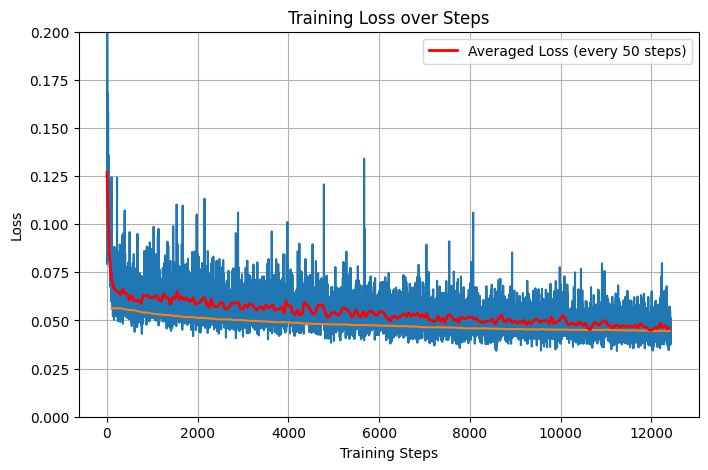

In [2]:
plt.figure(figsize=(8,5))
plt.plot(steps, losses)
plt.plot(test_steps, test_losses)
# Plot averaged loss every 50 steps
avg_losses = [np.mean(losses[i:i+50]) for i in range(0, len(losses), 50)]
plt.plot(range(0, len(losses), 50), avg_losses, color='red', linewidth=2, label='Averaged Loss (every 50 steps)')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Training Loss over Steps')
plt.legend()
plt.ylim([0,0.2])
# plt.xlim([0,8])
plt.grid()